# 🧹 EDA: Airbnb Listing Data Exploration

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MultiLabelBinarizer
import ast

sns.set(style='whitegrid')

## 2. Load and Preview Data

In [3]:
df = pd.read_csv('data/listings.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2772, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21797474,https://www.airbnb.com/rooms/21797474,20250319035134,2025-03-19,city scrape,7 Southover Close Westbury On Trym Bristol,"Beautiful House 4 bedrooms, set in the beautif...",NaN,https://a0.muscache.com/pictures/865838a6-ca9a...,158665944,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
1,45434492,https://www.airbnb.com/rooms/45434492,20250319035134,2025-03-19,city scrape,Double room in peaceful home,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,39358353,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
2,797137345244026756,https://www.airbnb.com/rooms/797137345244026756,20250319035134,2025-03-19,city scrape,Bright flat in central Clifton,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,27568683,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
3,1313695117463755982,https://www.airbnb.com/rooms/1313695117463755982,20250319035134,2025-03-19,city scrape,Clifton Village 7 bed,7 bedroom two bathroom apartment in Clifton vi...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,19404394,...,NaN,NaN,NaN,NaN,f,6,6,0,0,NaN
4,50021882,https://www.airbnb.com/rooms/50021882,20250319035134,2025-03-19,previous scrape,Bright two bedroom space with bathroom,NaN,NaN,https://a0.muscache.com/pictures/1897845b-99fa...,30844161,...,5.0,4.82,4.91,NaN,f,3,0,3,0,0.24


## 3. Dataset Overview & Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2772 non-null   int64  
 1   listing_url                                   2772 non-null   object 
 2   scrape_id                                     2772 non-null   int64  
 3   last_scraped                                  2772 non-null   object 
 4   source                                        2772 non-null   object 
 5   name                                          2772 non-null   object 
 6   description                                   2726 non-null   object 
 7   neighborhood_overview                         1437 non-null   object 
 8   picture_url                                   2772 non-null   object 
 9   host_id                                       2772 non-null   i

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2772.0,NaN,NaN,NaN,660696298860496000.0,530404794311222912.0,70820.0,42948446.25,803970128135208960.0,1152723955114193152.0,1379139316646375424.0
listing_url,2772,2772,https://www.airbnb.com/rooms/21797474,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,2772.0,NaN,NaN,NaN,20250319035134.0,0.0,20250319035134.0,20250319035134.0,20250319035134.0,20250319035134.0,20250319035134.0
last_scraped,2772,1,2025-03-19,2772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,2772,2,city scrape,2134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
calculated_host_listings_count,2772.0,NaN,NaN,NaN,14.360029,34.259021,1.0,1.0,2.0,6.0,148.0
calculated_host_listings_count_entire_homes,2772.0,NaN,NaN,NaN,13.237374,32.783972,0.0,1.0,1.0,4.0,140.0
calculated_host_listings_count_private_rooms,2772.0,NaN,NaN,NaN,0.83153,1.457236,0.0,0.0,0.0,1.0,9.0
calculated_host_listings_count_shared_rooms,2772.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Missing Values

In [6]:
# Count of missing values per column
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated                2772
neighbourhood_group_cleansed    2772
license                         2772
host_neighbourhood              2670
neighbourhood                   1335
neighborhood_overview           1335
host_about                      1155
beds                             641
bathrooms                        639
price                            639
estimated_revenue_l365d          639
host_response_time               582
host_response_rate               582
host_location                    542
review_scores_checkin            366
first_review                     366
last_review                      366
review_scores_accuracy           366
review_scores_cleanliness        366
reviews_per_month                366
dtype: int64

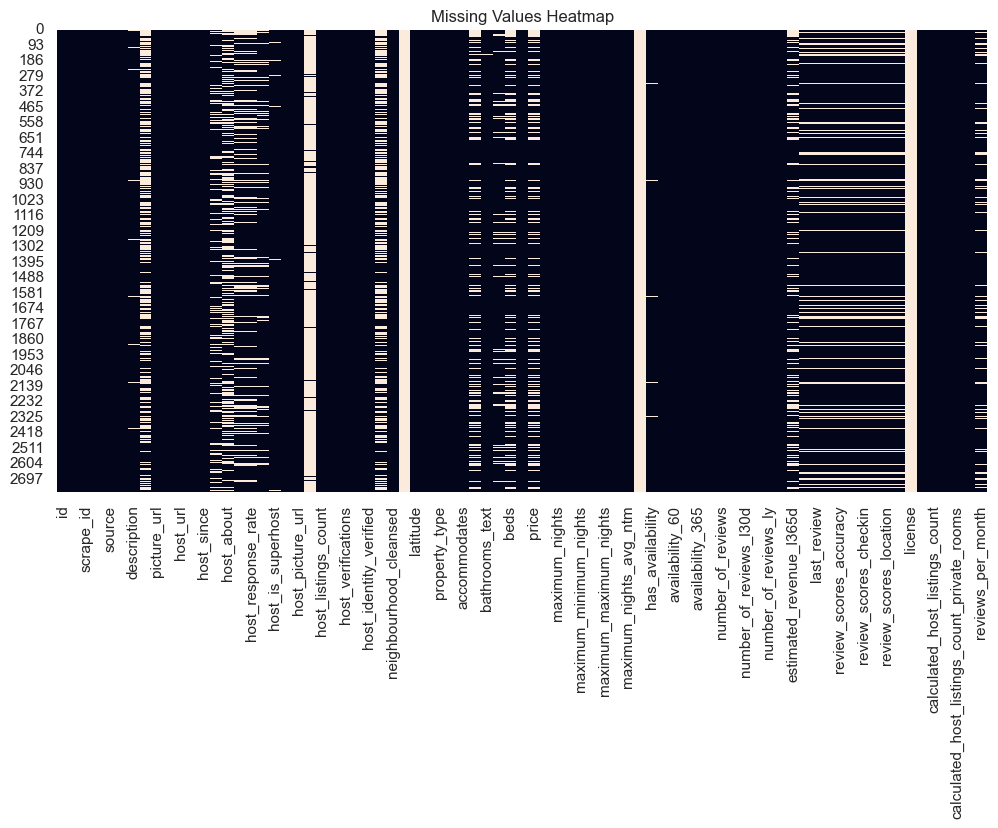

In [7]:
# Visualize missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

## 5. Feature Types and Examples

In [8]:
column_info = pd.DataFrame({
    'Feature': df.columns,
    'Example Value': df.iloc[0].values
})
pd.set_option('display.max_rows', None)
display(column_info)

,Feature,Example Value
0,id,21797474
1,listing_url,https://www.airbnb.com/rooms/21797474
2,scrape_id,20250319035134
3,last_scraped,2025-03-19
4,source,city scrape
5,name,7 Southover Close Westbury On Trym Bristol
6,description,"Beautiful House 4 bedrooms, set in the beautif..."
7,neighborhood_overview,NaN
8,picture_url,https://a0.muscache.com/pictures/865838a6-ca9a...
9,host_id,158665944


## 6. Drop Irrelevant Features
These include IDs, URLs, and media-related columns.

In [9]:
irrelevant_features = [
    'id', 'host_id', 'host_url', 'listing_url', 'scrape_id', 'last_scraped',
    'host_thumbnail_url', 'host_picture_url', 'calendar_last_scraped',
    'source', 'picture_url', 'host_name', 'host_verifications', 'property_type'
]
df.drop(columns=irrelevant_features, inplace=True)
df.shape

(2772, 65)

## 7. Visual EDA

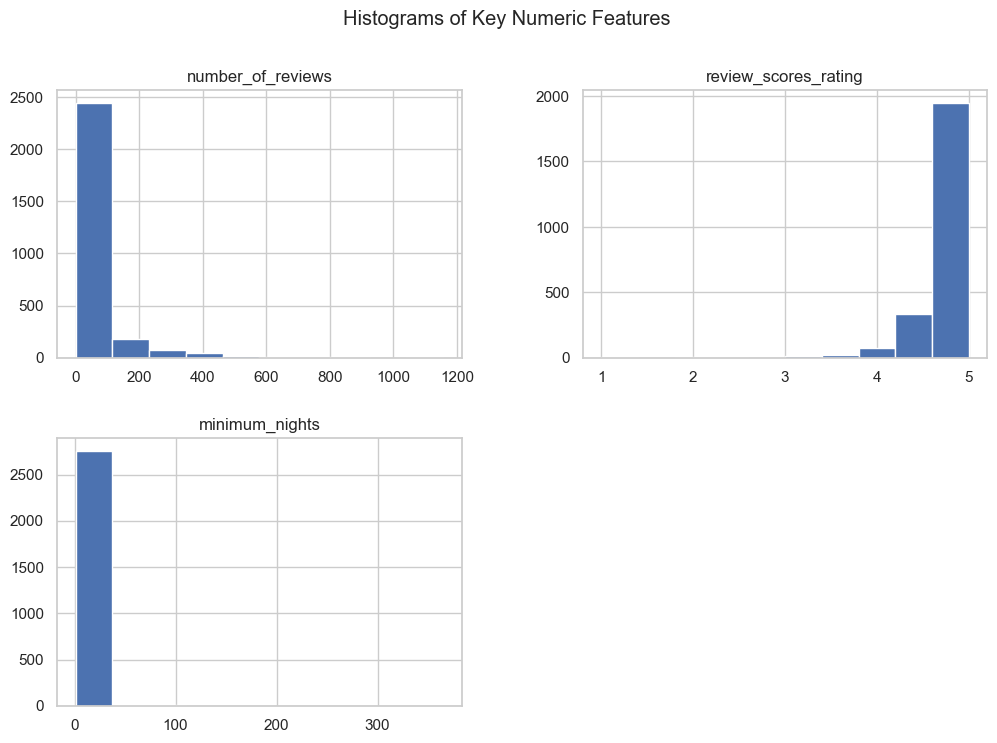

In [10]:
df[['price', 'number_of_reviews', 'review_scores_rating', 'minimum_nights']].hist(figsize=(12, 8))
plt.suptitle('Histograms of Key Numeric Features')
plt.show()

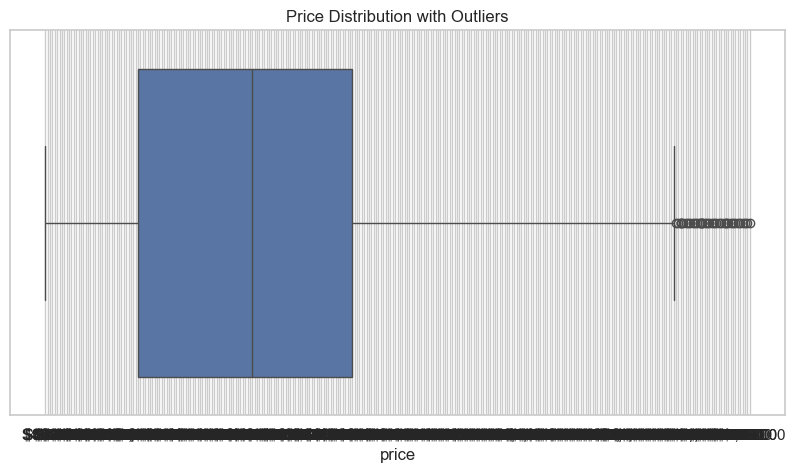

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Price Distribution with Outliers')
plt.show()

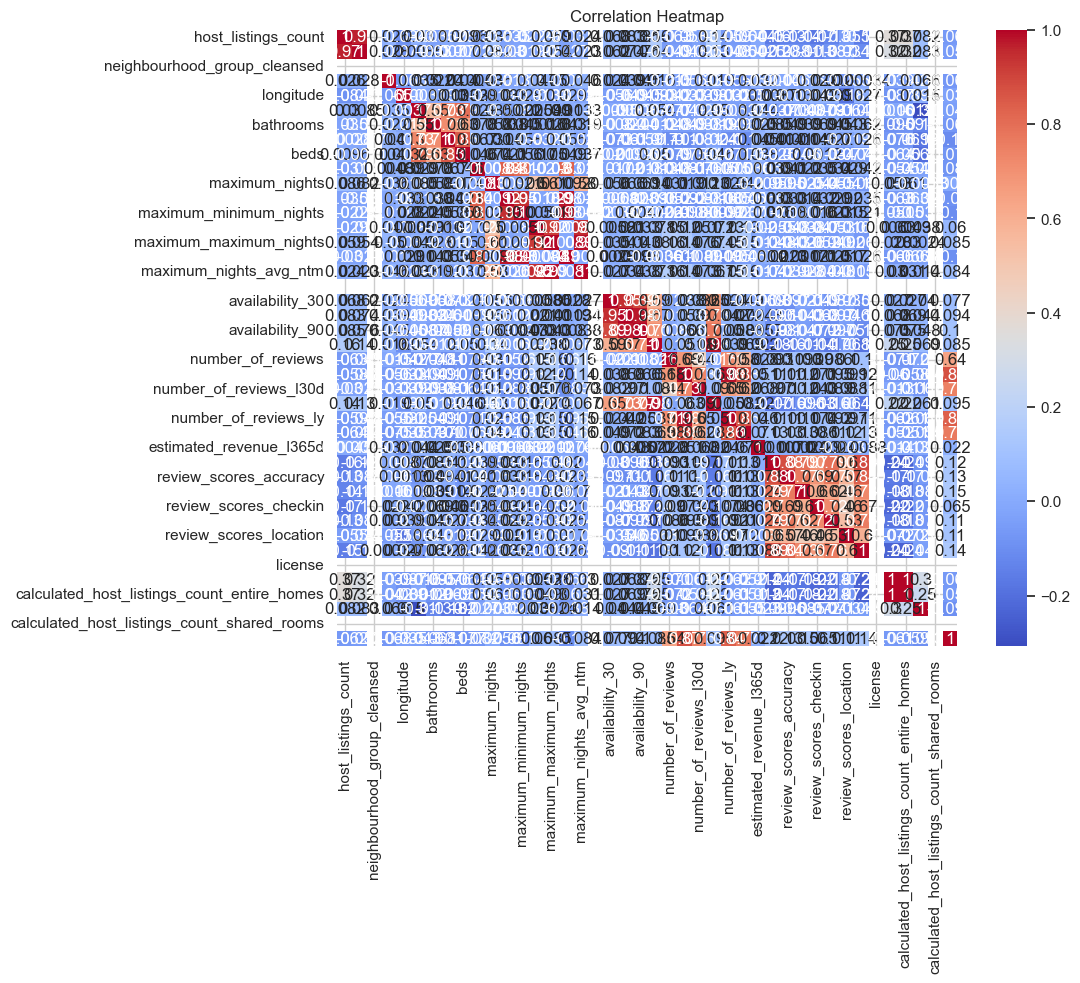

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()